In [1]:
import os, glob, random, numpy as np
from tqdm import tqdm
import rasterio
from rasterio.transform import from_bounds
import albumentations as A
import cv2
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
BASE         = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"
SRC_IMG_DIR  = f"{BASE}/trainingdata/DATASET/images"
SRC_MASK_DIR = f"{BASE}/trainingdata/DATASET/masks"

# Augmented tiles saved here — separate from originals
AUG_IMG_DIR  = f"{BASE}/trainingdata/DATASET_AUG/images"
AUG_MASK_DIR = f"{BASE}/trainingdata/DATASET_AUG/masks"

os.makedirs(AUG_IMG_DIR,  exist_ok=True)
os.makedirs(AUG_MASK_DIR, exist_ok=True)

SEED            = 42
random.seed(SEED); np.random.seed(SEED)

# How many augmented copies to generate per original tile
# Rare-class tiles get more copies (see RARE_MULTIPLIER)
BASE_MULTIPLIER = 2       # every tile gets 2 augmented versions
RARE_MULTIPLIER = 6       # tiles with rare classes get 6 versions

# Classes considered rare — oversample these tiles heavily
RARE_CLASSES    = [7, 9, 2, 6]   # waterbody_point, utility_poly, road, water
IGNORE_CLASSES  = [4, 5, 8]      # railway, bridge, utility — remap to background

print(f"Source images : {SRC_IMG_DIR}")
print(f"Source masks  : {SRC_MASK_DIR}")
print(f"Output images : {AUG_IMG_DIR}")
print(f"Output masks  : {AUG_MASK_DIR}")

# ═══════════════════════════════════════════════════════════════════════════════
# AUGMENTATION PIPELINES
# Three pipelines of increasing aggressiveness — randomly selected per tile
# ═══════════════════════════════════════════════════════════════════════════════

# Pipeline A — Geometric transforms (safe, always valid for segmentation)
pipeline_geometric = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.75),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(
        shift_limit  = 0.1,
        scale_limit  = 0.2,
        rotate_limit = 45,
        border_mode  = cv2.BORDER_REFLECT_101,
        p            = 0.7,
    ),
])

# Pipeline B — Photometric transforms (simulate different sensors/times of day)
pipeline_photometric = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=1.0),
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40,
                             val_shift_limit=30, p=1.0),
    ], p=0.9),
    A.OneOf([
        A.CLAHE(clip_limit=6.0, tile_grid_size=(8, 8), p=1.0),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
        A.UnsharpMask(blur_limit=(3, 7), sigma_limit=0.5, p=1.0),
    ], p=0.5),
    A.RandomGamma(gamma_limit=(70, 130), p=0.4),
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.3),
])

# Pipeline C — Degradation transforms (simulate clouds, haze, sensor noise)
pipeline_degradation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 9), p=1.0),
        A.MotionBlur(blur_limit=(3, 9), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(20, 100), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.08), intensity=(0.1, 0.6), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.85, 1.15), per_channel=True, p=1.0),
    ], p=0.6),
    A.OneOf([
        # Simulate haze / atmospheric scattering
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.1, p=1.0),
        A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5),
                         angle_lower=0.5, num_flare_circles_lower=1,
                         num_flare_circles_upper=3, src_radius=100, p=1.0),
        A.RandomShadow(shadow_roi=(0, 0, 1, 1), num_shadows_lower=1,
                       num_shadows_upper=3, shadow_dimension=5, p=1.0),
    ], p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
])

# Pipeline D — Geospatial distortions (simulate projection/orthorectification errors)
pipeline_geospatial = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.4,
                         border_mode=cv2.BORDER_REFLECT_101, p=1.0),
        A.OpticalDistortion(distort_limit=0.3, shift_limit=0.1,
                            border_mode=cv2.BORDER_REFLECT_101, p=1.0),
        A.ElasticTransform(alpha=200, sigma=200 * 0.05,
                           border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    ], p=0.8),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                       rotate_limit=30, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
])

# Pipeline E — CutMix-style occlusion (simulate building shadows, tree cover)
pipeline_occlusion = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.CoarseDropout(
        max_holes    = 16,
        max_height   = 64,
        max_width    = 64,
        min_holes    = 4,
        min_height   = 16,
        min_width    = 16,
        fill_value   = 0,
        p            = 0.8,
    ),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.ISONoise(p=1.0),
    ], p=0.3),
])

PIPELINES = [
    pipeline_geometric,
    pipeline_photometric,
    pipeline_degradation,
    pipeline_geospatial,
    pipeline_occlusion,
]
PIPELINE_NAMES = ["geometric", "photometric", "degradation", "geospatial", "occlusion"]

# ═══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════════════════
def is_rare_tile(mask: np.ndarray) -> bool:
    """Returns True if this tile contains pixels from any rare class."""
    for cls in RARE_CLASSES:
        if (mask == cls).sum() > 0:
            return True
    return False

def remap_ignore_classes(mask: np.ndarray) -> np.ndarray:
    """Remap absent/ignored classes to background."""
    mask = mask.copy()
    for cls in IGNORE_CLASSES:
        mask[mask == cls] = 0
    return mask

def save_tile(img: np.ndarray, mask: np.ndarray,
              out_img_path: str, out_mask_path: str,
              src_img_profile: dict, src_mask_profile: dict):
    """Save augmented image and mask as GeoTIFF, preserving rasterio metadata."""
    # Image: H W C → C H W
    img_chw = np.transpose(img, (2, 0, 1))

    img_profile = src_img_profile.copy()
    img_profile.update({
        "height": img.shape[0],
        "width":  img.shape[1],
        "count":  img_chw.shape[0],
        "dtype":  "uint8",
    })
    with rasterio.open(out_img_path, "w", **img_profile) as dst:
        dst.write(img_chw)

    mask_profile = src_mask_profile.copy()
    mask_profile.update({
        "height": mask.shape[0],
        "width":  mask.shape[1],
        "count":  1,
        "dtype":  "uint8",
    })
    with rasterio.open(out_mask_path, "w", **mask_profile) as dst:
        dst.write(mask.astype(np.uint8)[np.newaxis, :, :])

def augment_and_save(img_path: str, mask_path: str, n_copies: int):
    """Apply n_copies augmentations to a single tile and save results."""
    stem = os.path.splitext(os.path.basename(img_path))[0]

    with rasterio.open(img_path) as src:
        img         = src.read()                          # C H W
        img         = np.transpose(img, (1, 2, 0))        # H W C
        img_profile = src.profile

    with rasterio.open(mask_path) as src:
        mask         = src.read(1)                        # H W
        mask_profile = src.profile

    mask = remap_ignore_classes(mask)

    saved = 0
    attempts = 0
    max_attempts = n_copies * 3

    while saved < n_copies and attempts < max_attempts:
        attempts += 1
        pipeline = random.choice(PIPELINES)
        pname    = PIPELINE_NAMES[PIPELINES.index(pipeline)]

        try:
            result   = pipeline(image=img, mask=mask)
            aug_img  = result["image"]
            aug_mask = result["mask"]
        except Exception as e:
            continue

        # Reject if augmentation wiped out all foreground pixels
        if (aug_mask > 0).sum() == 0:
            continue

        out_name     = f"{stem}_aug{saved:02d}_{pname}"
        out_img_path  = os.path.join(AUG_IMG_DIR,  f"{out_name}.tif")
        out_mask_path = os.path.join(AUG_MASK_DIR, f"{out_name}.tif")

        save_tile(aug_img, aug_mask, out_img_path, out_mask_path,
                  img_profile, mask_profile)
        saved += 1

    return saved

# ═══════════════════════════════════════════════════════════════════════════════
# ALSO COPY ORIGINALS into AUG folder
# Training will use DATASET_AUG which contains originals + augmented
# ═══════════════════════════════════════════════════════════════════════════════
def copy_originals():
    img_paths  = sorted(glob.glob(f"{SRC_IMG_DIR}/*.tif"))
    mask_paths = sorted(glob.glob(f"{SRC_MASK_DIR}/*.tif"))

    print(f"\nCopying {len(img_paths)} original tiles into AUG folder...")
    for img_path, mask_path in tqdm(zip(img_paths, mask_paths), total=len(img_paths)):
        stem = os.path.basename(img_path)

        with rasterio.open(img_path) as src:
            img     = src.read()
            profile = src.profile
        with rasterio.open(os.path.join(AUG_IMG_DIR, stem), "w", **profile) as dst:
            dst.write(img)

        with rasterio.open(mask_path) as src:
            mask    = remap_ignore_classes(src.read(1))
            profile = src.profile
        profile.update({"dtype": "uint8"})
        with rasterio.open(os.path.join(AUG_MASK_DIR, stem), "w", **profile) as dst:
            dst.write(mask.astype(np.uint8)[np.newaxis, :, :])

# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    img_paths  = sorted(glob.glob(f"{SRC_IMG_DIR}/*.tif"))
    mask_paths = sorted(glob.glob(f"{SRC_MASK_DIR}/*.tif"))

    assert len(img_paths) > 0,              f"No images found in {SRC_IMG_DIR}"
    assert len(img_paths) == len(mask_paths), \
        f"Mismatch: {len(img_paths)} images vs {len(mask_paths)} masks"

    print(f"\nFound {len(img_paths)} source tiles")
    print(f"Base multiplier  : {BASE_MULTIPLIER}x per tile")
    print(f"Rare multiplier  : {RARE_MULTIPLIER}x for tiles with classes {RARE_CLASSES}")

    # Step 1 — copy originals
    copy_originals()

    # Step 2 — generate augmentations
    total_saved  = 0
    rare_count   = 0
    normal_count = 0

    print(f"\nGenerating augmentations...")
    for img_path, mask_path in tqdm(zip(img_paths, mask_paths),
                                     total=len(img_paths), desc="Augmenting"):
        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        if is_rare_tile(mask):
            n_copies = RARE_MULTIPLIER
            rare_count += 1
        else:
            n_copies = BASE_MULTIPLIER
            normal_count += 1

        saved       = augment_and_save(img_path, mask_path, n_copies)
        total_saved += saved

    # Step 3 — summary
    aug_imgs  = sorted(glob.glob(f"{AUG_IMG_DIR}/*.tif"))
    aug_masks = sorted(glob.glob(f"{AUG_MASK_DIR}/*.tif"))

    print("\n" + "═" * 55)
    print("Augmentation complete")
    print("═" * 55)
    print(f"Original tiles      : {len(img_paths)}")
    print(f"  Normal tiles (x{BASE_MULTIPLIER}) : {normal_count}")
    print(f"  Rare tiles   (x{RARE_MULTIPLIER}) : {rare_count}")
    print(f"New aug tiles saved : {total_saved}")
    print(f"Total in AUG folder : {len(aug_imgs)} images / {len(aug_masks)} masks")
    print(f"\nOutput dir : {AUG_IMG_DIR}")
    print(f"           : {AUG_MASK_DIR}")
    print("\nUpdate your training CFG:")
    print(f'  "img_dir":  "{AUG_IMG_DIR}"')
    print(f'  "mask_dir": "{AUG_MASK_DIR}"')

    # Step 4 — quick pixel distribution check on augmented masks
    print("\nVerifying class distribution in augmented masks...")
    counts = np.zeros(10, dtype=np.int64)
    CLASS_NAMES = [
        "background", "built_up_area", "road", "road_centre_line",
        "railway", "bridge", "water_body_line", "waterbody_point",
        "utility", "utility_poly",
    ]
    for p in tqdm(aug_masks[:200], desc="Sampling 200 masks"):   # sample for speed
        with rasterio.open(p) as src:
            m = src.read(1).flatten()
        for c in range(10):
            counts[c] += (m == c).sum()

    total = counts.sum()
    print("\nClass distribution (sample of 200 aug masks):")
    for i, (n, c) in enumerate(zip(CLASS_NAMES, counts)):
        print(f"  {i} {n:22s}: {int(c):>10,}  ({100*c/total:.3f}%)")

Source images : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/images
Source masks  : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/masks
Output images : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/images
Output masks  : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/masks

Found 4819 source tiles
Base multiplier  : 2x per tile
Rare multiplier  : 6x for tiles with classes [7, 9, 2, 6]

Copying 4819 original tiles into AUG folder...


100%|██████████| 4819/4819 [02:21<00:00, 34.06it/s]



Generating augmentations...


Augmenting: 100%|██████████| 4819/4819 [13:07<00:00,  6.12it/s]



═══════════════════════════════════════════════════════
Augmentation complete
═══════════════════════════════════════════════════════
Original tiles      : 4819
  Normal tiles (x2) : 2579
  Rare tiles   (x6) : 2240
New aug tiles saved : 18598
Total in AUG folder : 23417 images / 23417 masks

Output dir : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/images
           : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/masks

Update your training CFG:
  "img_dir":  "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/images"
  "mask_dir": "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/masks"

Verifying class distribution in augmented masks...


Sampling 200 masks: 100%|██████████| 200/200 [00:00<00:00, 254.83it/s]


Class distribution (sample of 200 aug masks):
  0 background            : 35,542,769  (67.792%)
  1 built_up_area         :  6,001,310  (11.447%)
  2 road                  :  5,259,072  (10.031%)
  3 road_centre_line      :  5,625,649  (10.730%)
  4 railway               :          0  (0.000%)
  5 bridge                :          0  (0.000%)
  6 water_body_line       :          0  (0.000%)
  7 waterbody_point       :          0  (0.000%)
  8 utility               :          0  (0.000%)
  9 utility_poly          :          0  (0.000%)


In [ ]:
import os, gc, glob, json, random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch",
                "albumentations", "rasterio", "scikit-learn", "timm", "-q"])

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

gc.collect()
torch.cuda.empty_cache()

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

BASE = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"

# ── PATH DIAGNOSTICS ─────────────────────────────────────────────────────────
AUG_IMGS  = f"{BASE}/trainingdata/DATASET_AUG/images"
AUG_MASKS = f"{BASE}/trainingdata/DATASET_AUG/masks"
ORIG_IMGS  = f"{BASE}/trainingdata/DATASET/images"
ORIG_MASKS = f"{BASE}/trainingdata/DATASET/masks"
CKPT_PATH  = f"{BASE}/CHECKPOINTS/best_model.pth"

aug_ready  = os.path.exists(AUG_IMGS) and len(glob.glob(f"{AUG_IMGS}/*.tif")) > 0
ckpt_ready = os.path.exists(CKPT_PATH)

IMG_DIR  = AUG_IMGS  if aug_ready  else ORIG_IMGS
MASK_DIR = AUG_MASKS if aug_ready  else ORIG_MASKS

print(f"\nAUG dataset ready  : {aug_ready}  → using: {IMG_DIR}")
print(f"Checkpoint ready   : {ckpt_ready} → {CKPT_PATH}")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
CFG = {
    "img_dir":          IMG_DIR,
    "mask_dir":         MASK_DIR,
    "save_dir":         f"{BASE}/CHECKPOINTS",

    "num_classes":      10,
    "tile_size":        512,

    "encoder":          "mit_b3",
    "encoder_weights":  "imagenet",

    "batch_size":       16,
    "num_epochs":       120,
    "lr":               5e-5,
    "weight_decay":     1e-2,
    "val_split":        0.2,
    "num_workers":      8,

    "ce_weight":        0.3,
    "dice_weight":      0.4,
    "focal_weight":     0.3,

    "patience":         25,
    "min_delta":        1e-4,

    "resume":           ckpt_ready,   # auto-detected
    "resume_ckpt":      CKPT_PATH,
}

os.makedirs(CFG["save_dir"], exist_ok=True)

# ── CLASS INFO ────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "railway", "bridge", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,   0,   0  ], [255, 0,   0  ], [255, 255, 0  ], [255, 165, 0  ],
    [128, 0,   128], [165, 42,  42 ], [0,   0,   255], [0,   255, 255],
    [0,   255, 0  ], [255, 105, 180],
], dtype=np.uint8)

PIXEL_COUNTS = np.array([
    647_435_523,
    388_862_220,
     49_832_874,
    131_981_531,
              1,   # railway  — absent
              1,   # bridge   — absent
     44_439_682,
         53_439,
             93,   # utility  — near-absent
        666_574,
], dtype=np.float64)

ACTIVE_CLASSES = [1, 2, 3, 6, 7, 9]
IGNORE_CLASSES = [4, 5, 8]

print("\nPixel distribution (actual):")
total = PIXEL_COUNTS.sum()
for i, (n, c) in enumerate(zip(CLASS_NAMES, PIXEL_COUNTS)):
    flag = " ← IGNORED" if i in IGNORE_CLASSES else ""
    print(f"  {i} {n:22s}: {int(c):>12,}  ({100*c/total:.4f}%){flag}")

# ── CLASS WEIGHTS ─────────────────────────────────────────────────────────────
raw_weights = np.zeros(10, dtype=np.float64)
for i in range(10):
    if i not in IGNORE_CLASSES:
        raw_weights[i] = 1.0 / np.log1p(PIXEL_COUNTS[i])

active_mask = np.array([i not in IGNORE_CLASSES for i in range(10)])
if active_mask.sum() > 0:
    raw_weights[active_mask] /= raw_weights[active_mask].mean()
raw_weights = np.clip(raw_weights, 0, 20.0)

class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

print("\nCalibrated class weights:")
for i, (n, w) in enumerate(zip(CLASS_NAMES, raw_weights)):
    print(f"  {i} {n:22s}: {w:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════════
class SVAMITVADataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.img_paths[idx]) as src:
            img = src.read().astype(np.float32) / 255.0
            img = np.transpose(img, (1, 2, 0))

        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.int64)

        for cls in IGNORE_CLASSES:
            mask[mask == cls] = 0

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"].long()
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask).long()

        return img, mask

    def get_sample_weight(self, idx):
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).flatten()
        rare_pixels = sum((mask == c).sum() for c in [7, 9, 2, 6])
        return float(rare_pixels) + 1.0

# ── AUGMENTATIONS ─────────────────────────────────────────────────────────────
# Light online augmentation — heavy augmentation already done offline
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                       rotate_limit=20, p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.3),
        A.OpticalDistortion(distort_limit=0.2),
        A.ElasticTransform(alpha=120, sigma=6),
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.1),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8)),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 60)),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── DATALOADERS ───────────────────────────────────────────────────────────────
all_imgs  = sorted(glob.glob(f"{CFG['img_dir']}/*.tif"))
all_masks = sorted(glob.glob(f"{CFG['mask_dir']}/*.tif"))

assert len(all_imgs) > 0, \
    f"No .tif files found in {CFG['img_dir']} — check path!"
assert len(all_imgs) == len(all_masks), \
    f"Mismatch: {len(all_imgs)} images vs {len(all_masks)} masks"
for i, m in zip(all_imgs, all_masks):
    assert os.path.basename(i) == os.path.basename(m), \
        f"Filename mismatch: {i} vs {m}"

print(f"\nTotal tiles found : {len(all_imgs)}")

indices = list(range(len(all_imgs)))
train_idx, val_idx = train_test_split(
    indices, test_size=CFG["val_split"], random_state=SEED
)

train_imgs  = [all_imgs[i]  for i in train_idx]
train_masks = [all_masks[i] for i in train_idx]
val_imgs    = [all_imgs[i]  for i in val_idx]
val_masks   = [all_masks[i] for i in val_idx]

for name, data in [("train_imgs", train_imgs), ("train_masks", train_masks),
                   ("val_imgs",   val_imgs),   ("val_masks",   val_masks)]:
    with open(os.path.join(CFG["save_dir"], f"{name}.json"), "w") as f:
        json.dump(data, f)

train_dataset = SVAMITVADataset(train_imgs, train_masks, train_transform)
val_dataset   = SVAMITVADataset(val_imgs,   val_masks,   val_transform)

print("Computing tile sample weights (oversampling rare classes)...")
sample_weights = [
    train_dataset.get_sample_weight(i)
    for i in tqdm(range(len(train_dataset)), desc="Weights")
]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size         = CFG["batch_size"],
    sampler            = sampler,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 4,
    persistent_workers = True,
    drop_last          = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = CFG["batch_size"],
    shuffle            = False,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 4,
    persistent_workers = True,
)

print(f"Train tiles : {len(train_dataset)}")
print(f"Val tiles   : {len(val_dataset)}")
print(f"Batch size  : {CFG['batch_size']}")

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════════
model = smp.Segformer(
    encoder_name    = CFG["encoder"],
    encoder_weights = CFG["encoder_weights"],
    in_channels     = 3,
    classes         = CFG["num_classes"],
    activation      = None,
).to(DEVICE)

try:
    model = torch.compile(model)
    print("\ntorch.compile() enabled")
except Exception:
    print("\ntorch.compile() not available — skipping")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : SegFormer / {CFG['encoder']}")
print(f"Parameters : {total_params:,}")
print(f"GPU free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ═══════════════════════════════════════════════════════════════════════════════
# LOSS
# ═══════════════════════════════════════════════════════════════════════════════
ce_loss    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
dice_loss  = smp.losses.DiceLoss(
    mode    = "multiclass",
    classes = ACTIVE_CLASSES,
    smooth  = 1.0,
)
focal_loss = smp.losses.FocalLoss(mode="multiclass", gamma=3.0)

def criterion(outputs, masks):
    return (CFG["ce_weight"]    * ce_loss(outputs, masks)    +
            CFG["dice_weight"]  * dice_loss(outputs, masks)  +
            CFG["focal_weight"] * focal_loss(outputs, masks))

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZER + SCHEDULER
# ═══════════════════════════════════════════════════════════════════════════════
encoder_params, decoder_params = [], []
for name, param in model.named_parameters():
    (encoder_params if "encoder" in name else decoder_params).append(param)

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": CFG["lr"],     "weight_decay": CFG["weight_decay"]},
    {"params": decoder_params, "lr": CFG["lr"] * 5, "weight_decay": CFG["weight_decay"]},
])

def warmup_cosine(epoch, warmup=5, total=120):
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda = lambda ep: warmup_cosine(ep, warmup=5, total=CFG["num_epochs"]),
)

scaler = GradScaler("cuda")

# ═══════════════════════════════════════════════════════════════════════════════
# RESUME FROM CHECKPOINT
# Model weights only — optimizer intentionally reset to avoid
# inheriting NaN momentum from the previous corrupted run
# ═══════════════════════════════════════════════════════════════════════════════
best_miou   = 0.0
start_epoch = 0

if CFG["resume"] and os.path.exists(CFG["resume_ckpt"]):
    print(f"\nLoading checkpoint: {CFG['resume_ckpt']}")
    ckpt  = torch.load(CFG["resume_ckpt"], map_location=DEVICE, weights_only=False)
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f"  Missing keys  : {missing[:5]}")
    if unexpected:
        print(f"  Unexpected keys: {unexpected[:5]}")
    best_miou   = ckpt["val_miou"]
    start_epoch = ckpt["epoch"]
    print(f"  ✅ Resumed from epoch {start_epoch} | best mIoU = {best_miou:.4f}")
    print("  Optimizer reset fresh — no NaN momentum inherited")
else:
    print("\nStarting from scratch")

# ═══════════════════════════════════════════════════════════════════════════════
# METRICS
# ═══════════════════════════════════════════════════════════════════════════════
def fast_miou(preds, masks, active_classes=ACTIVE_CLASSES):
    ious = {}
    for cls in active_classes:
        pred_c = (preds == cls)
        true_c = (masks == cls)
        inter  = (pred_c & true_c).sum().item()
        union  = (pred_c | true_c).sum().item()
        if union > 0:
            ious[cls] = inter / union
    miou = float(np.mean(list(ious.values()))) if ious else 0.0
    return ious, miou

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
history           = {"train_loss": [], "val_loss": [], "val_miou": []}
patience_ct       = 0
nan_batches_total = 0

print("\n" + "═" * 65)
print(f"Active classes  : {[CLASS_NAMES[c] for c in ACTIVE_CLASSES]}")
print(f"Ignored classes : {[CLASS_NAMES[c] for c in IGNORE_CLASSES]}")
print(f"Starting epoch  : {start_epoch + 1} / {CFG['num_epochs']}")
print(f"Best mIoU so far: {best_miou:.4f}")
print("═" * 65)

for epoch in range(start_epoch, CFG["num_epochs"]):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss  = 0.0
    valid_steps = 0
    nan_batches = 0

    for imgs, masks in tqdm(train_loader,
                            desc=f"Ep {epoch+1:03d} train", leave=False):
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, masks)

        # ── Guard 1: NaN/Inf loss before backward ─────────────────────────────
        if torch.isnan(loss) or torch.isinf(loss):
            nan_batches += 1
            optimizer.zero_grad()
            torch.cuda.empty_cache()
            continue
        # ─────────────────────────────────────────────────────────────────────

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # ── Guard 2: NaN gradients after unscale ──────────────────────────────
        has_nan_grad = any(
            p.grad is not None and
            (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
            for p in model.parameters()
        )
        if has_nan_grad:
            nan_batches += 1
            optimizer.zero_grad()
            scaler.update()          # must reset scaler state after unscale_()
            torch.cuda.empty_cache()
            continue
        # ─────────────────────────────────────────────────────────────────────

        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        scaler.step(optimizer)
        scaler.update()

        train_loss  += loss.item()
        valid_steps += 1

    scheduler.step()

    if nan_batches > 0:
        nan_batches_total += nan_batches
        print(f"  ⚠️  {nan_batches} NaN batches skipped "
              f"(total: {nan_batches_total})")

    if valid_steps == 0:
        print("  💀 All batches NaN — model corrupted. "
              "Set resume=False to retrain from scratch.")
        break

    train_loss /= valid_steps

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss     = 0.0
    val_steps    = 0
    all_ious     = {c: [] for c in ACTIVE_CLASSES}

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader,
                                desc=f"Ep {epoch+1:03d} val  ", leave=False):
            imgs  = imgs.to(DEVICE,  non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(imgs)
                loss    = criterion(outputs, masks)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            preds     = torch.argmax(outputs, dim=1)
            val_loss += loss.item()
            val_steps += 1
            ious, _   = fast_miou(preds, masks)
            for cls, iou in ious.items():
                all_ious[cls].append(iou)

    val_loss      /= max(val_steps, 1)
    per_class_iou  = {c: float(np.mean(v)) for c, v in all_ious.items() if v}
    val_miou       = float(np.mean(list(per_class_iou.values()))) \
                     if per_class_iou else 0.0

    torch.cuda.empty_cache()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    improved = val_miou > best_miou + CFG["min_delta"]
    if improved:
        best_miou   = val_miou
        patience_ct = 0
        torch.save({
            "epoch":          epoch + 1,
            "model_state":    model.state_dict(),
            "optim_state":    optimizer.state_dict(),
            "val_miou":       val_miou,
            "cfg":            CFG,
            "active_classes": ACTIVE_CLASSES,
        }, os.path.join(CFG["save_dir"], "best_model.pth"))
        tag = f"  ✅ best={best_miou:.4f}"
    else:
        patience_ct += 1
        tag = f"  (patience {patience_ct}/{CFG['patience']})"

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Ep {epoch+1:03d}/{CFG['num_epochs']} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | LR: {lr_now:.2e}{tag}")

    if (epoch + 1) % 10 == 0:
        print("  Per-class IoU:")
        for cls in ACTIVE_CLASSES:
            iou = per_class_iou.get(cls, 0.0)
            print(f"    {cls} {CLASS_NAMES[cls]:22s}: {iou:.4f}")

    if patience_ct >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch + 1}.")
        break

print(f"\nBest Val mIoU : {best_miou:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

ax1.plot(ep, history["train_loss"], label="Train")
ax1.plot(ep, history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(ep, history["val_miou"], color="green", label="mIoU")
ax2.set_title("Val mIoU (active classes only)")
ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "training_curves.png"), dpi=150)
plt.show()

Device : cuda
GPU    : Tesla V100-PCIE-32GB
Memory : 34.1 GB
Free   : 16.9 GB

AUG dataset ready  : True  → using: /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_AUG/images
Checkpoint ready   : True → /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS/best_model.pth

Pixel distribution (actual):
  0 background            :  647,435,523  (51.2507%)
  1 built_up_area         :  388,862,220  (30.7821%)
  2 road                  :   49,832,874  (3.9447%)
  3 road_centre_line      :  131,981,531  (10.4476%)
  4 railway               :            1  (0.0000%) ← IGNORED
  5 bridge                :            1  (0.0000%) ← IGNORED
  6 water_body_line       :   44,439,682  (3.5178%)
  7 waterbody_point       :       53,439  (0.0042%)
  8 utility               :           93  (0.0000%) ← IGNORED
  9 utility_poly          :      666,574  (0.0528%)

Calibrated class weights:
  0 background            : 0.7969
  1 built_up_area         : 0.8174
  2 road        

Weights: 100%|██████████| 18733/18733 [00:54<00:00, 341.10it/s]


Train tiles : 18733
Val tiles   : 4684
Batch size  : 16

torch.compile() enabled
Model      : SegFormer / mit_b3
Parameters : 44,600,522
GPU free   : 16.7 GB

Loading checkpoint: /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS/best_model.pth
  Missing keys  : ['_orig_mod.encoder.patch_embed1.proj.weight', '_orig_mod.encoder.patch_embed1.proj.bias', '_orig_mod.encoder.patch_embed1.norm.weight', '_orig_mod.encoder.patch_embed1.norm.bias', '_orig_mod.encoder.patch_embed2.proj.weight']
  Unexpected keys: ['encoder.patch_embed1.proj.weight', 'encoder.patch_embed1.proj.bias', 'encoder.patch_embed1.norm.weight', 'encoder.patch_embed1.norm.bias', 'encoder.patch_embed2.proj.weight']
  ✅ Resumed from epoch 75 | best mIoU = 0.2914
  Optimizer reset fresh — no NaN momentum inherited

═════════════════════════════════════════════════════════════════
Active classes  : ['built_up_area', 'road', 'road_centre_line', 'water_body_line', 'waterbody_point', 'utility_poly']
Ignored classes : 

  ⚠️  5 NaN batches skipped (total: 5)


Ep 076/120 | Train: 0.8707 | Val: 0.7581 | mIoU: 0.1224 | LR: 2.00e-05  (patience 1/25)


Ep 077/120 | Train: 0.7105 | Val: 0.6729 | mIoU: 0.1690 | LR: 3.00e-05  (patience 2/25)


Ep 078 train:  19%|█▉        | 224/1170 [01:13<05:02,  3.13it/s]

In [ ]:
import os
print(os.getpid())

Classes to rasterize:
  1 built_up_area          (polygon)
  2 road                   (polygon)
  3 road_centre_line       (line)
  4 water_body             (polygon)
  5 water_body_line        (line)
  6 waterbody_point        (point)
  7 utility                (point)
  8 utility_poly           (polygon)
DATA PREPARATION PIPELINE
Tile size : 1024 x 1024
Stride    : 768  (overlap = 256px)
Min FG    : 0.5%

────────────────────────────────────────────────────────────
Processing: 28996_NADALA_ORTHO
────────────────────────────────────────────────────────────
Target CRS : EPSG:32643
Loading shapefiles...
  ✅ built_up_area         : 27503 features → CRS EPSG:32643
  ✅ road                  :   968 features → CRS EPSG:32643
  ✅ road_centre_line      :  1527 features → CRS EPSG:32643
  ✅ water_body            :    67 features → CRS EPSG:32643
  ✅ water_body_line       :   234 features → CRS EPSG:32643
  ✅ waterbody_point       :    20 features → CRS EPSG:32643
  ✅ utility               :  1

  Tiling 28996_NADALA_ORTHO: 100%|██████████| 1224/1224 [01:08<00:00, 17.79it/s]


    Saved: 837 | Skipped (no FG): 387 | Skipped (edge): 0

────────────────────────────────────────────────────────────
Processing: TIMMOWAL_37695_ORI
────────────────────────────────────────────────────────────
Target CRS : EPSG:32643
Loading shapefiles...
  ✅ built_up_area         : 27503 features → CRS EPSG:32643
  ✅ road                  :   968 features → CRS EPSG:32643
  ✅ road_centre_line      :  1527 features → CRS EPSG:32643
  ✅ water_body            :    67 features → CRS EPSG:32643
  ✅ water_body_line       :   234 features → CRS EPSG:32643
  ✅ waterbody_point       :    20 features → CRS EPSG:32643
  ✅ utility               :  1227 features → CRS EPSG:32643
  ✅ utility_poly          :  1193 features → CRS EPSG:32643
Rasterizing mask...
Mask coverage: 194,699,302 / 949,545,200 px (20.50% foreground)
  class 1 built_up_area       : 101,490,485 px (10.688%)
  class 2 road                :  2,208,206 px (0.233%)
  class 3 road_centre_line    : 33,374,491 px (3.515%)
  class 4 w

  Tiling TIMMOWAL_37695_ORI: 100%|██████████| 1640/1640 [01:15<00:00, 21.71it/s] 


    Saved: 826 | Skipped (no FG): 814 | Skipped (edge): 0

────────────────────────────────────────────────────────────
Processing: fattu_bhila
────────────────────────────────────────────────────────────
Target CRS : EPSG:3857
Loading shapefiles...
  ✅ built_up_area         : 27503 features → CRS EPSG:3857
  ✅ road                  :   968 features → CRS EPSG:3857
  ✅ road_centre_line      :  1527 features → CRS EPSG:3857
  ✅ water_body            :    67 features → CRS EPSG:3857
  ✅ water_body_line       :   234 features → CRS EPSG:3857
  ✅ waterbody_point       :    18 features → CRS EPSG:3857
  ✅ utility               :  1227 features → CRS EPSG:3857
  ✅ utility_poly          :  1193 features → CRS EPSG:3857
Rasterizing mask...
Mask coverage: 93,944,924 / 461,861,972 px (20.34% foreground)
  class 1 built_up_area       : 47,451,346 px (10.274%)
  class 2 road                :  2,534,821 px (0.549%)
  class 3 road_centre_line    : 17,203,918 px (3.725%)
  class 4 water_body         

  Tiling fattu_bhila: 100%|██████████| 783/783 [00:32<00:00, 24.42it/s]


    Saved: 460 | Skipped (no FG): 323 | Skipped (edge): 0

────────────────────────────────────────────────────────────
Processing: bagga
────────────────────────────────────────────────────────────
Target CRS : EPSG:3857
Loading shapefiles...
  ✅ built_up_area         : 27503 features → CRS EPSG:3857
  ✅ road                  :   968 features → CRS EPSG:3857
  ✅ road_centre_line      :  1527 features → CRS EPSG:3857
  ✅ water_body            :    67 features → CRS EPSG:3857
  ✅ water_body_line       :   234 features → CRS EPSG:3857
  ✅ waterbody_point       :    18 features → CRS EPSG:3857
  ✅ utility               :  1227 features → CRS EPSG:3857
  ✅ utility_poly          :  1193 features → CRS EPSG:3857
Rasterizing mask...
Mask coverage: 103,942,595 / 611,061,962 px (17.01% foreground)
  class 1 built_up_area       : 61,547,106 px (10.072%)
  class 2 road                :  1,341,832 px (0.220%)
  class 3 road_centre_line    : 24,312,832 px (3.979%)
  class 4 water_body          :  2

  Tiling bagga: 100%|██████████| 1050/1050 [00:43<00:00, 23.96it/s]


    Saved: 621 | Skipped (no FG): 429 | Skipped (edge): 0

PIPELINE COMPLETE
Total tiles saved : 2744
Output images     : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/images
Output masks      : /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/masks

Pixel distribution across all tiles:
  0 background            : 1,764,710,366  (61.3323%)
  1 built_up_area         :  693,864,908  (24.1152%)
  2 road                  :   13,185,924  (0.4583%)
  3 road_centre_line      :  199,538,875  (6.9350%)
  4 water_body            :   83,284,429  (2.8945%)
  5 water_body_line       :   75,806,214  (2.6346%)
  6 waterbody_point       :      543,668  (0.0189%)
  7 utility               :   44,707,486  (1.5538%)
  8 utility_poly          :    1,650,674  (0.0574%)

Stats saved → /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/stats.json
Use these pixel_counts to calibrate class weights in training.

Generating samp

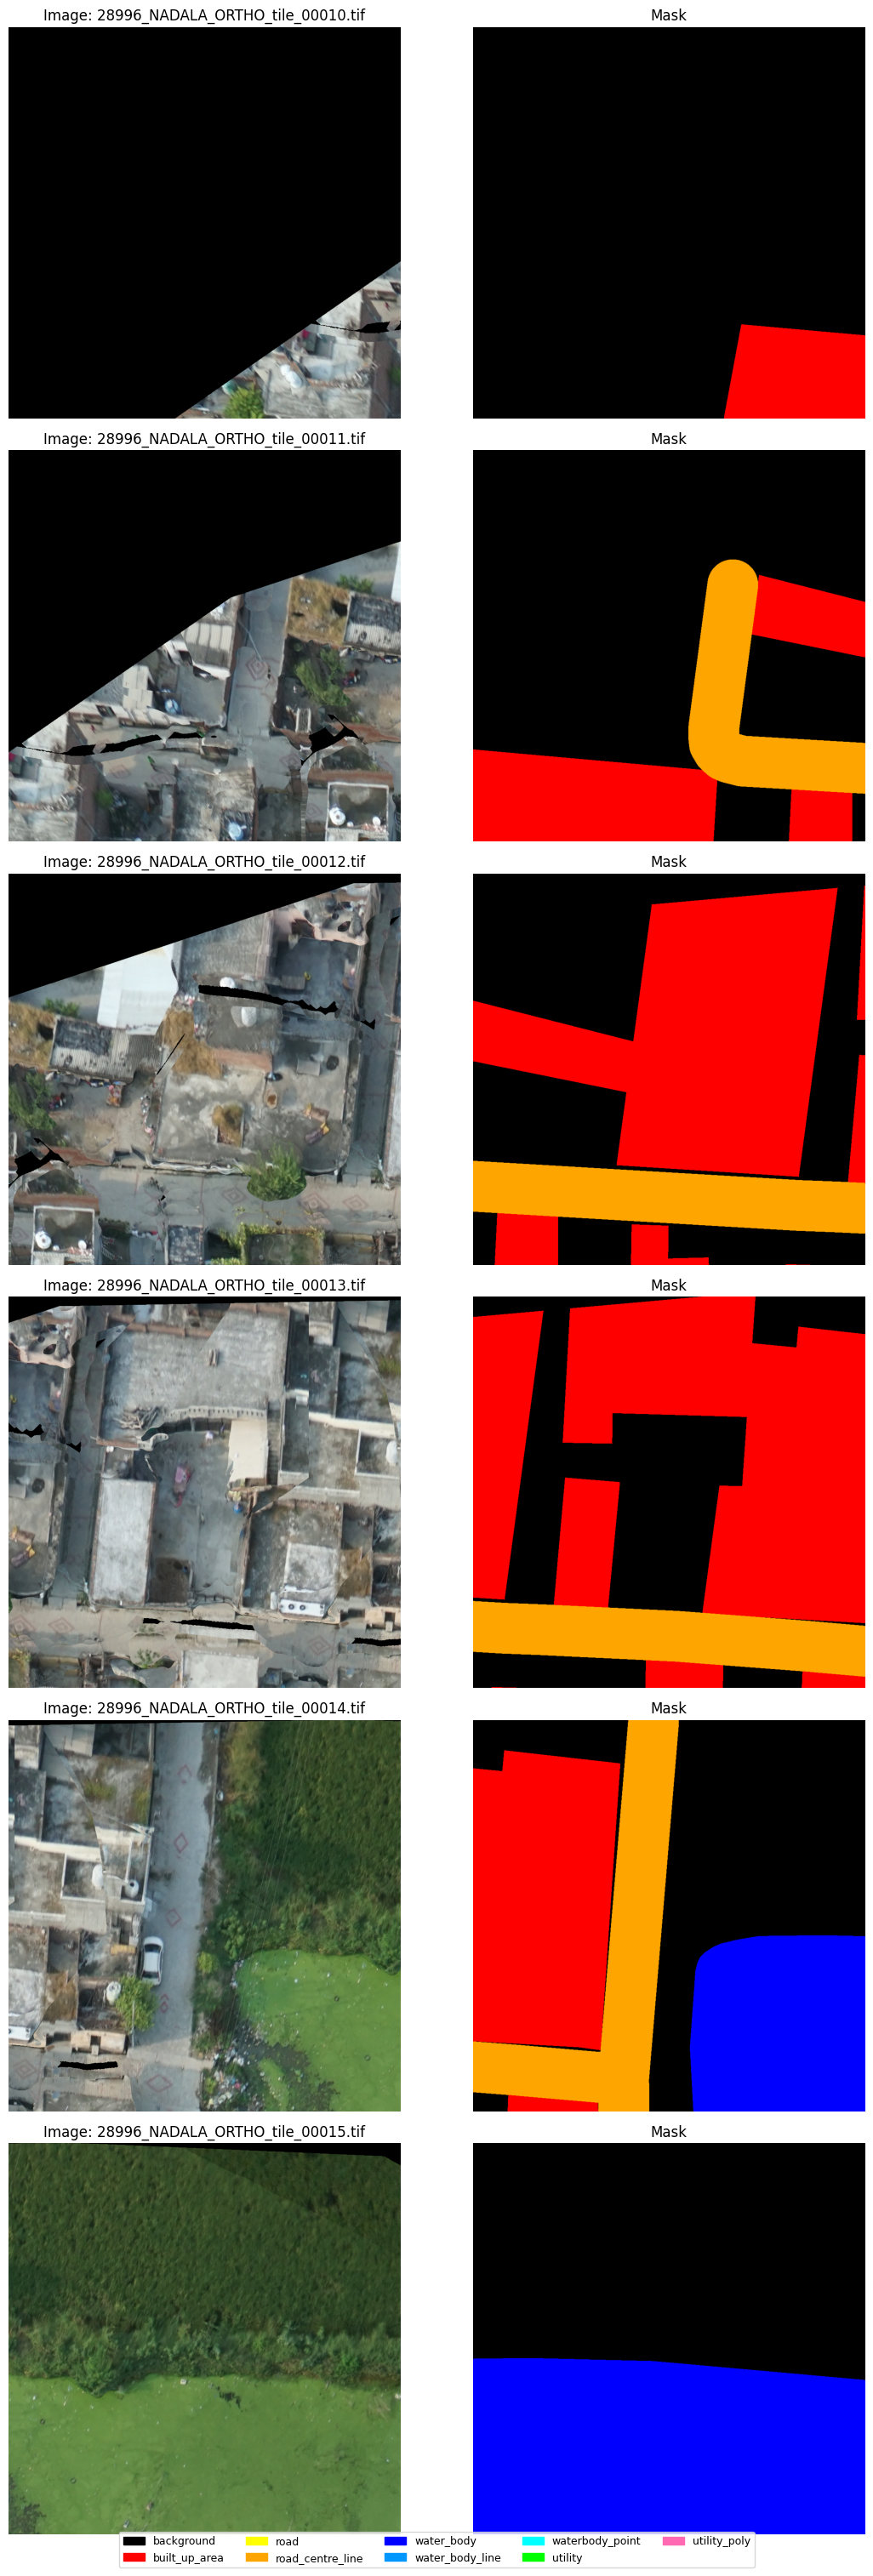

Sample saved → /home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/sample_tiles.png

Copy this into your training script CFG:

CFG = {
    "img_dir":      "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/images",
    "mask_dir":     "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET_1024/masks",
    "num_classes":  9,
    "tile_size":    1024,
    ...
}

PIXEL_COUNTS = np.array([1764710366, 693864908, 13185924, 199538875, 83284429, 75806214, 543668, 44707486, 1650674], dtype=np.float64)
CLASS_NAMES  = ['background', 'built_up_area', 'road', 'road_centre_line', 'water_body', 'water_body_line', 'waterbody_point', 'utility', 'utility_poly']



In [1]:
"""
COMPLETE DATA PREPARATION PIPELINE
===================================
1. Reprojects all shapefiles to match each raster CRS
2. Rasterizes shapefiles into single-band label masks
3. Tiles rasters + masks at 1024x1024 with overlap
4. Filters out tiles with too little foreground
5. Saves pixel count stats for training class weights

Output structure:
  DATASET_1024/
    images/   ← 3-band uint8 RGB tiles
    masks/    ← single-band uint8 label tiles (0=background, 1=built_up, ...)
    stats.json
"""

import os, gc, glob, json, warnings
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from rasterio.transform import from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
BASE    = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"
SHP_DIR = f"{BASE}/shp-file2"

# Output directory — completely fresh, separate from old 512px tiles
OUT_BASE  = f"{BASE}/trainingdata/DATASET_1024"
OUT_IMGS  = f"{OUT_BASE}/images"
OUT_MASKS = f"{OUT_BASE}/masks"
os.makedirs(OUT_IMGS,  exist_ok=True)
os.makedirs(OUT_MASKS, exist_ok=True)

TILE_SIZE       = 1024
STRIDE          = 768       # 256px overlap — reduces edge artifacts
MIN_FG_RATIO    = 0.005     # tile must have ≥ 0.5% foreground pixels to keep
POINT_BUFFER_M  = 5.0       # metres — buffer for Point geometries
LINE_BUFFER_M   = 2.0       # metres — buffer for Line geometries

# ── SOURCE RASTERS ────────────────────────────────────────────────────────────
RASTERS = [
    f"{BASE}/28996_NADALA_ORTHO.tif",
    f"{BASE}/TIMMOWAL_37695_ORI.tif",
    f"{BASE}/fattu_bhila.tif",
    f"{BASE}/bagga.tif",
]

# ── CLASS DEFINITIONS ─────────────────────────────────────────────────────────
# Order matters — higher class_id painted LAST wins overlapping pixels
# Drop railway(4 rows), bridge(9 rows) — too sparse to learn
# Keep: background(0), built_up(1), road(2), road_centre_line(3),
#        water_body(4), water_body_line(5), waterbody_point(6),
#        utility(7), utility_poly(8)

CLASS_DEFS = [
    # (class_id, name,              shp_path,                          geom_type)
    (1, "built_up_area",    f"{SHP_DIR}/Built_Up_Area_typ.shp",  "polygon"),
    (2, "road",             f"{SHP_DIR}/Road.shp",               "polygon"),
    (3, "road_centre_line", f"{SHP_DIR}/Road_Centre_Line.shp",   "line"),
    (4, "water_body",       f"{SHP_DIR}/Water_Body.shp",         "polygon"),
    (5, "water_body_line",  f"{SHP_DIR}/Water_Body_Line.shp",    "line"),
    (6, "waterbody_point",  f"{SHP_DIR}/Waterbody_Point.shp",    "point"),
    (7, "utility",          f"{SHP_DIR}/Utility.shp",            "point"),
    (8, "utility_poly",     f"{SHP_DIR}/Utility_Poly_.shp",      "polygon"),
]

NUM_CLASSES = 9    # 0..8

CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "water_body", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,   0,   0  ],   # 0 background
    [255, 0,   0  ],   # 1 built_up_area
    [255, 255, 0  ],   # 2 road
    [255, 165, 0  ],   # 3 road_centre_line
    [0,   0,   255],   # 4 water_body
    [0,   150, 255],   # 5 water_body_line
    [0,   255, 255],   # 6 waterbody_point
    [0,   255, 0  ],   # 7 utility
    [255, 105, 180],   # 8 utility_poly
], dtype=np.uint8)

print("Classes to rasterize:")
for cls_id, name, _, geom in CLASS_DEFS:
    print(f"  {cls_id} {name:22s} ({geom})")

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD & REPROJECT SHAPEFILES
# ═══════════════════════════════════════════════════════════════════════════════
def load_shapefiles(target_crs: str) -> list:
    """Load all shapefiles, reproject to target_crs, buffer lines/points."""
    layers = []
    for cls_id, name, shp_path, geom_type in CLASS_DEFS:
        if not os.path.exists(shp_path):
            print(f"  ⚠️  Missing: {shp_path}")
            continue
        gdf = gpd.read_file(shp_path)

        # Drop null geometries
        gdf = gdf[gdf.geometry.notna()].copy()
        if len(gdf) == 0:
            print(f"  ⚠️  {name}: no valid geometries")
            continue

        # Reproject to target CRS
        if str(gdf.crs) != str(target_crs):
            gdf = gdf.to_crs(target_crs)

        # Buffer points and lines so they're visible as pixels
        if geom_type == "point":
            gdf["geometry"] = gdf.geometry.buffer(POINT_BUFFER_M)
        elif geom_type == "line":
            gdf["geometry"] = gdf.geometry.buffer(LINE_BUFFER_M)

        # Only keep geometries that are polygon-like after buffering
        gdf = gdf[~gdf.geometry.is_empty]

        if len(gdf) > 0:
            layers.append((cls_id, name, gdf))
            print(f"  ✅ {name:22s}: {len(gdf):5d} features → CRS {target_crs}")
        else:
            print(f"  ⚠️  {name}: empty after reprojection/buffer")

    return layers

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — RASTERIZE ONE FULL IMAGE → FULL MASK
# ═══════════════════════════════════════════════════════════════════════════════
def rasterize_mask(raster_path: str, layers: list) -> np.ndarray:
    """
    Burn all shapefile layers into a single H x W uint8 label mask
    aligned to the given raster.
    """
    with rasterio.open(raster_path) as src:
        H, W      = src.height, src.width
        transform = src.transform
        crs       = src.crs

    mask = np.zeros((H, W), dtype=np.uint8)   # 0 = background

    for cls_id, name, gdf in layers:
        # Clip to raster bounds for speed
        from shapely.geometry import box
        with rasterio.open(raster_path) as src:
            bounds = src.bounds
        raster_box = box(*bounds)
        gdf_clip   = gdf[gdf.geometry.intersects(raster_box)].copy()

        if len(gdf_clip) == 0:
            continue

        shapes = [(geom, cls_id) for geom in gdf_clip.geometry if geom is not None]
        if not shapes:
            continue

        burned = rasterize(
            shapes,
            out_shape = (H, W),
            transform = transform,
            fill      = 0,
            dtype     = np.uint8,
            all_touched = True,   # include pixels touched by geometry edge
        )
        # Higher class_id overwrites lower — paint on top
        mask[burned > 0] = burned[burned > 0]

    return mask

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — TILE IMAGE + MASK AT 1024 x 1024
# ═══════════════════════════════════════════════════════════════════════════════
def tile_image_and_mask(raster_path: str, mask: np.ndarray,
                         prefix: str, pixel_counts: np.ndarray) -> int:
    """Slide a 1024x1024 window over the raster, save valid tiles."""
    with rasterio.open(raster_path) as src:
        H, W      = src.height, src.width
        transform = src.transform
        crs       = src.crs
        profile   = src.profile

    n_saved = 0
    n_skip_small  = 0
    n_skip_nofg   = 0
    tile_idx = 0

    ys = list(range(0, H - TILE_SIZE + 1, STRIDE))
    xs = list(range(0, W - TILE_SIZE + 1, STRIDE))

    # Make sure we always cover the last row/col
    if ys[-1] + TILE_SIZE < H:
        ys.append(H - TILE_SIZE)
    if xs[-1] + TILE_SIZE < W:
        xs.append(W - TILE_SIZE)

    total = len(ys) * len(xs)

    with rasterio.open(raster_path) as src:
        pbar = tqdm(total=total, desc=f"  Tiling {prefix}", leave=True)

        for y in ys:
            for x in xs:
                tile_idx += 1
                window    = Window(x, y, TILE_SIZE, TILE_SIZE)

                # Read RGB only (first 3 bands — drop NIR/alpha band 4)
                img_tile = src.read([1, 2, 3], window=window)   # 3 H W

                # Skip if tile is smaller than expected (edge of raster)
                if img_tile.shape[1] < TILE_SIZE or img_tile.shape[2] < TILE_SIZE:
                    n_skip_small += 1
                    pbar.update(1)
                    continue

                # Corresponding mask tile
                mask_tile = mask[y:y+TILE_SIZE, x:x+TILE_SIZE]
                if mask_tile.shape[0] < TILE_SIZE or mask_tile.shape[1] < TILE_SIZE:
                    n_skip_small += 1
                    pbar.update(1)
                    continue

                # Skip tiles with too little foreground
                fg_ratio = (mask_tile > 0).sum() / (TILE_SIZE * TILE_SIZE)
                if fg_ratio < MIN_FG_RATIO:
                    n_skip_nofg += 1
                    pbar.update(1)
                    continue

                # Accumulate pixel counts for class weight calculation
                for c in range(NUM_CLASSES):
                    pixel_counts[c] += (mask_tile == c).sum()

                # Tile geotransform
                tile_transform = rasterio.transform.from_origin(
                    transform.c + x * transform.a,
                    transform.f + y * transform.e,
                    transform.a,
                    -transform.e,
                )

                tile_name = f"{prefix}_tile_{tile_idx:05d}.tif"

                # Save image tile
                img_profile = {
                    "driver":    "GTiff",
                    "dtype":     "uint8",
                    "width":     TILE_SIZE,
                    "height":    TILE_SIZE,
                    "count":     3,
                    "crs":       crs,
                    "transform": tile_transform,
                    "compress":  "lzw",
                }
                with rasterio.open(f"{OUT_IMGS}/{tile_name}", "w", **img_profile) as dst:
                    dst.write(img_tile)

                # Save mask tile
                mask_profile = img_profile.copy()
                mask_profile["count"] = 1
                with rasterio.open(f"{OUT_MASKS}/{tile_name}", "w", **mask_profile) as dst:
                    dst.write(mask_tile[np.newaxis, :, :])

                n_saved += 1
                pbar.update(1)

        pbar.close()

    print(f"    Saved: {n_saved} | Skipped (no FG): {n_skip_nofg} "
          f"| Skipped (edge): {n_skip_small}")
    return n_saved

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — VISUALISE SAMPLE TILES
# ═══════════════════════════════════════════════════════════════════════════════
def visualise_samples(n=6):
    img_paths  = sorted(glob.glob(f"{OUT_IMGS}/*.tif"))
    mask_paths = sorted(glob.glob(f"{OUT_MASKS}/*.tif"))
    if len(img_paths) == 0:
        print("No tiles to visualise yet.")
        return

    # Pick tiles that have decent foreground
    sample_paths = []
    for ip, mp in zip(img_paths, mask_paths):
        with rasterio.open(mp) as src:
            m = src.read(1)
        if (m > 0).sum() / m.size > 0.05:
            sample_paths.append((ip, mp))
        if len(sample_paths) >= n:
            break

    if not sample_paths:
        sample_paths = list(zip(img_paths[:n], mask_paths[:n]))

    fig, axes = plt.subplots(len(sample_paths), 2,
                              figsize=(12, 5 * len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]

    for i, (ip, mp) in enumerate(sample_paths):
        with rasterio.open(ip) as src:
            img = np.transpose(src.read(), (1, 2, 0))
        with rasterio.open(mp) as src:
            msk = src.read(1)

        rgb_mask = np.zeros((*msk.shape, 3), dtype=np.uint8)
        for c, color in enumerate(COLOR_MAP):
            rgb_mask[msk == c] = color

        axes[i][0].imshow(img); axes[i][0].set_title(f"Image: {os.path.basename(ip)}"); axes[i][0].axis("off")
        axes[i][1].imshow(rgb_mask); axes[i][1].set_title("Mask"); axes[i][1].axis("off")

    patches = [mpatches.Patch(color=COLOR_MAP[i]/255., label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=5,
               fontsize=9, bbox_to_anchor=(0.5, -0.01))
    plt.tight_layout()
    plt.savefig(f"{OUT_BASE}/sample_tiles.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Sample saved → {OUT_BASE}/sample_tiles.png")

# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    total_saved  = 0

    print("=" * 60)
    print("DATA PREPARATION PIPELINE")
    print(f"Tile size : {TILE_SIZE} x {TILE_SIZE}")
    print(f"Stride    : {STRIDE}  (overlap = {TILE_SIZE - STRIDE}px)")
    print(f"Min FG    : {MIN_FG_RATIO*100:.1f}%")
    print("=" * 60)

    for raster_path in RASTERS:
        raster_name = os.path.splitext(os.path.basename(raster_path))[0]
        print(f"\n{'─'*60}")
        print(f"Processing: {raster_name}")
        print(f"{'─'*60}")

        # Get CRS of this raster
        with rasterio.open(raster_path) as src:
            target_crs = src.crs
        print(f"Target CRS : {target_crs}")

        # Load + reproject shapefiles to match this raster
        print("Loading shapefiles...")
        layers = load_shapefiles(target_crs)

        # Rasterize full mask
        print("Rasterizing mask...")
        mask = rasterize_mask(raster_path, layers)

        # Report mask coverage before tiling
        total_px = mask.size
        fg_px    = (mask > 0).sum()
        print(f"Mask coverage: {fg_px:,} / {total_px:,} px "
              f"({100*fg_px/total_px:.2f}% foreground)")
        for c in range(1, NUM_CLASSES):
            cnt = (mask == c).sum()
            if cnt > 0:
                print(f"  class {c} {CLASS_NAMES[c]:20s}: {cnt:>10,} px "
                      f"({100*cnt/total_px:.3f}%)")

        # Tile
        n = tile_image_and_mask(raster_path, mask, raster_name, pixel_counts)
        total_saved += n

        del mask
        gc.collect()

    # ── FINAL STATS ───────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)
    print(f"Total tiles saved : {total_saved}")
    print(f"Output images     : {OUT_IMGS}")
    print(f"Output masks      : {OUT_MASKS}")

    total_px = pixel_counts.sum()
    print(f"\nPixel distribution across all tiles:")
    for c in range(NUM_CLASSES):
        pct = 100 * pixel_counts[c] / total_px if total_px > 0 else 0
        print(f"  {c} {CLASS_NAMES[c]:22s}: {pixel_counts[c]:>12,}  ({pct:.4f}%)")

    # Save stats for training script
    stats = {
        "num_classes":   NUM_CLASSES,
        "class_names":   CLASS_NAMES,
        "pixel_counts":  pixel_counts.tolist(),
        "total_tiles":   total_saved,
        "tile_size":     TILE_SIZE,
        "stride":        STRIDE,
        "img_dir":       OUT_IMGS,
        "mask_dir":      OUT_MASKS,
    }
    stats_path = f"{OUT_BASE}/stats.json"
    with open(stats_path, "w") as f:
        json.dump(stats, f, indent=2)
    print(f"\nStats saved → {stats_path}")
    print("Use these pixel_counts to calibrate class weights in training.")

    # ── SAMPLE VISUALISATION ──────────────────────────────────────────────────
    print("\nGenerating sample tile visualisations...")
    visualise_samples(n=6)

    # ── TRAINING CONFIG SNIPPET ───────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Copy this into your training script CFG:")
    print("=" * 60)
    print(f"""
CFG = {{
    "img_dir":      "{OUT_IMGS}",
    "mask_dir":     "{OUT_MASKS}",
    "num_classes":  {NUM_CLASSES},
    "tile_size":    {TILE_SIZE},
    ...
}}

PIXEL_COUNTS = np.array({pixel_counts.tolist()}, dtype=np.float64)
CLASS_NAMES  = {CLASS_NAMES}
""")

In [1]:
"""
SPEED-OPTIMISED TRAINING
=========================
Key speed fixes:
1. Sample weights cached to disk — computed once, reused every run
2. num_workers tuned for 1024px tiles
3. persistent_workers only on val loader
4. pin_memory_device set correctly
5. epoch timing printed so you know actual speed
"""

import os, gc, glob, json, random, time
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch",
                "albumentations", "rasterio", "scikit-learn", "timm", "-q"])

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

gc.collect()
torch.cuda.empty_cache()

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True   # faster matmul on Ampere GPUs
torch.backends.cudnn.allow_tf32       = True   # faster conv on Ampere GPUs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

BASE = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
CFG = {
    "img_dir":          f"{BASE}/trainingdata/DATASET_1024/images",
    "mask_dir":         f"{BASE}/trainingdata/DATASET_1024/masks",
    "save_dir":         f"{BASE}/CHECKPOINTS_1024-2",

    "num_classes":      9,
    "tile_size":        1024,

    "encoder":          "mit_b3",
    "encoder_weights":  "imagenet",

    "batch_size":       4,
    "accum_steps":      2,          # effective batch = 8
    "num_epochs":       80,
    "lr":               5e-5,
    "weight_decay":     1e-2,
    "val_split":        0.2,
    "num_workers":      4,          # reduced from 8 — sweet spot for 1024px

    "ce_weight":        0.3,
    "dice_weight":      0.4,
    "focal_weight":     0.3,

    "patience":         20,
    "min_delta":        1e-4,

    "resume":           False,
    "resume_ckpt":      f"{BASE}/CHECKPOINTS_1024/best_model.pth",
}

os.makedirs(CFG["save_dir"], exist_ok=True)

CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "water_body", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,   0,   0  ], [255, 0,   0  ], [255, 255, 0  ], [255, 165, 0  ],
    [0,   0,   255], [0,   150, 255], [0,   255, 255],
    [0,   255, 0  ], [255, 105, 180],
], dtype=np.uint8)

PIXEL_COUNTS = np.array([
    1_764_710_366, 693_864_908, 13_185_924, 199_538_875,
    83_284_429, 75_806_214, 543_668, 44_707_486, 1_650_674,
], dtype=np.float64)

ACTIVE_CLASSES = list(range(1, 9))

print("\nPixel distribution:")
total = PIXEL_COUNTS.sum()
for i, (n, c) in enumerate(zip(CLASS_NAMES, PIXEL_COUNTS)):
    print(f"  {i} {n:22s}: {int(c):>14,}  ({100*c/total:.4f}%)")

raw_weights   = 1.0 / np.log1p(PIXEL_COUNTS)
raw_weights  /= raw_weights.mean()
raw_weights   = np.clip(raw_weights, 0, 20.0)
class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

# ═══════════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════════
class SegDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.img_paths[idx]) as src:
            img = src.read().astype(np.float32) / 255.0
            img = np.transpose(img, (1, 2, 0))

        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.int64)

        mask = np.clip(mask, 0, CFG["num_classes"] - 1)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"].long()
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask).long()

        return img, mask


def compute_sample_weights(mask_paths: list, save_dir: str,
                            rare_classes: list = [6, 8, 2, 5]) -> list:
    """
    Compute tile sample weights for WeightedRandomSampler.
    CACHED to disk — only computed once, reloaded on subsequent runs.
    This alone saves 5-10 minutes per training run on 2744 tiles.
    """
    cache_path = os.path.join(save_dir, "sample_weights.json")

    if os.path.exists(cache_path):
        print(f"Loading cached sample weights from {cache_path}")
        with open(cache_path) as f:
            weights = json.load(f)
        if len(weights) == len(mask_paths):
            return weights
        print("Cache size mismatch — recomputing...")

    print(f"Computing sample weights for {len(mask_paths)} tiles...")
    weights = []
    for p in tqdm(mask_paths, desc="Weights"):
        with rasterio.open(p) as src:
            mask = src.read(1).flatten()
        rare = sum((mask == c).sum() for c in rare_classes)
        weights.append(float(rare) + 1.0)

    with open(cache_path, "w") as f:
        json.dump(weights, f)
    print(f"Weights cached → {cache_path}")
    return weights

# ── AUGMENTATIONS ─────────────────────────────────────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.4),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.2),
        A.OpticalDistortion(distort_limit=0.15),
    ], p=0.2),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        A.CLAHE(clip_limit=4.0),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50)),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.4)),
    ], p=0.2),
    A.CoarseDropout(max_holes=6, max_height=64, max_width=64,
                    fill_value=0, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── DATALOADERS ───────────────────────────────────────────────────────────────
all_imgs  = sorted(glob.glob(f"{CFG['img_dir']}/*.tif"))
all_masks = sorted(glob.glob(f"{CFG['mask_dir']}/*.tif"))

assert len(all_imgs) > 0, f"No tiles in {CFG['img_dir']}"
assert len(all_imgs) == len(all_masks), \
    f"Mismatch: {len(all_imgs)} imgs vs {len(all_masks)} masks"

print(f"\nTotal tiles : {len(all_imgs)}")

indices = list(range(len(all_imgs)))
train_idx, val_idx = train_test_split(
    indices, test_size=CFG["val_split"], random_state=SEED
)

train_imgs  = [all_imgs[i]  for i in train_idx]
train_masks = [all_masks[i] for i in train_idx]
val_imgs    = [all_imgs[i]  for i in val_idx]
val_masks   = [all_masks[i] for i in val_idx]

for name, data in [("train_imgs", train_imgs), ("train_masks", train_masks),
                   ("val_imgs",   val_imgs),   ("val_masks",   val_masks)]:
    with open(os.path.join(CFG["save_dir"], f"{name}.json"), "w") as f:
        json.dump(data, f)

train_dataset = SegDataset(train_imgs, train_masks, train_transform)
val_dataset   = SegDataset(val_imgs,   val_masks,   val_transform)

# Cached weights — fast on second+ runs
sample_weights = compute_sample_weights(train_masks, CFG["save_dir"])
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size         = CFG["batch_size"],
    sampler            = sampler,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 2,
    persistent_workers = False,   # OFF for train — sampler reshuffles each epoch
    drop_last          = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = CFG["batch_size"],
    shuffle            = False,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 2,
    persistent_workers = True,    # ON for val — fixed order, safe to persist
)

print(f"Train tiles      : {len(train_dataset)}")
print(f"Val tiles        : {len(val_dataset)}")
print(f"Train batches    : {len(train_loader)}")
print(f"Val batches      : {len(val_loader)}")
print(f"Batch size       : {CFG['batch_size']}")
print(f"Effective batch  : {CFG['batch_size'] * CFG['accum_steps']}")

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════════
model = smp.Segformer(
    encoder_name    = CFG["encoder"],
    encoder_weights = CFG["encoder_weights"],
    in_channels     = 3,
    classes         = CFG["num_classes"],
    activation      = None,
).to(DEVICE)

# Gradient checkpointing — saves ~8GB VRAM, ~20% slower per step (worth it)
if hasattr(model.encoder, "set_grad_checkpointing"):
    model.encoder.set_grad_checkpointing(True)
    print("Gradient checkpointing : enabled")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : SegFormer-{CFG['encoder'].upper()}")
print(f"Parameters : {total_params:,}")
print(f"GPU free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ═══════════════════════════════════════════════════════════════════════════════
# LOSS
# ═══════════════════════════════════════════════════════════════════════════════
ce_loss    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
dice_loss  = smp.losses.DiceLoss(mode="multiclass", classes=ACTIVE_CLASSES, smooth=1.0)
focal_loss = smp.losses.FocalLoss(mode="multiclass", gamma=3.0)

def criterion(outputs, masks):
    return (CFG["ce_weight"]    * ce_loss(outputs, masks)    +
            CFG["dice_weight"]  * dice_loss(outputs, masks)  +
            CFG["focal_weight"] * focal_loss(outputs, masks))

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZER + SCHEDULER
# ═══════════════════════════════════════════════════════════════════════════════
encoder_params, decoder_params = [], []
for name, param in model.named_parameters():
    (encoder_params if "encoder" in name else decoder_params).append(param)

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": CFG["lr"],     "weight_decay": CFG["weight_decay"]},
    {"params": decoder_params, "lr": CFG["lr"] * 5, "weight_decay": CFG["weight_decay"]},
])

def warmup_cosine(epoch, warmup=5, total=80):
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda ep: warmup_cosine(ep, warmup=5, total=CFG["num_epochs"]),
)

scaler = GradScaler("cuda")

# ═══════════════════════════════════════════════════════════════════════════════
# RESUME
# ═══════════════════════════════════════════════════════════════════════════════
best_miou   = 0.0
start_epoch = 0

if CFG["resume"] and os.path.exists(CFG["resume_ckpt"]):
    print(f"\nLoading: {CFG['resume_ckpt']}")
    ckpt  = torch.load(CFG["resume_ckpt"], map_location=DEVICE, weights_only=False)
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    model.load_state_dict(state, strict=False)
    best_miou   = ckpt["val_miou"]
    start_epoch = ckpt["epoch"]
    print(f"  ✅ Resumed epoch {start_epoch} | mIoU={best_miou:.4f}")
else:
    print("\nTraining from scratch")

# ═══════════════════════════════════════════════════════════════════════════════
# METRICS
# ═══════════════════════════════════════════════════════════════════════════════
def compute_miou(preds, masks, active=ACTIVE_CLASSES):
    ious = {}
    for cls in active:
        pred_c = (preds == cls)
        true_c = (masks == cls)
        inter  = (pred_c & true_c).sum().item()
        union  = (pred_c | true_c).sum().item()
        if union > 0:
            ious[cls] = inter / union
    miou = float(np.mean(list(ious.values()))) if ious else 0.0
    return ious, miou

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
history           = {"train_loss": [], "val_loss": [], "val_miou": []}
patience_ct       = 0
nan_batches_total = 0

print("\n" + "═" * 70)
print(f"Model          : SegFormer-B3")
print(f"Tiles          : {len(all_imgs)} × {CFG['tile_size']}px")
print(f"Effective batch: {CFG['batch_size'] * CFG['accum_steps']}")
print(f"Epochs         : {start_epoch + 1} → {CFG['num_epochs']}")
print("═" * 70)

for epoch in range(start_epoch, CFG["num_epochs"]):

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    epoch_start = time.time()

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss  = 0.0
    valid_steps = 0
    nan_batches = 0
    optimizer.zero_grad()

    for step, (imgs, masks) in enumerate(tqdm(
            train_loader, desc=f"Ep {epoch+1:03d} train", leave=False)):

        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, masks) / CFG["accum_steps"]

        if torch.isnan(loss) or torch.isinf(loss):
            nan_batches += 1
            optimizer.zero_grad()
            torch.cuda.empty_cache()
            continue

        scaler.scale(loss).backward()

        if (step + 1) % CFG["accum_steps"] == 0:
            scaler.unscale_(optimizer)

            has_nan_grad = any(
                p.grad is not None and
                (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                for p in model.parameters()
            )
            if has_nan_grad:
                nan_batches += 1
                optimizer.zero_grad()
                scaler.update()
                torch.cuda.empty_cache()
                continue

            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss  += loss.item() * CFG["accum_steps"]
        valid_steps += 1

    scheduler.step()

    if nan_batches > 0:
        nan_batches_total += nan_batches
        print(f"  ⚠️  {nan_batches} NaN batches (total: {nan_batches_total})")

    if valid_steps == 0:
        print("  💀 All NaN — stopping.")
        break

    train_loss /= valid_steps
    train_time  = time.time() - epoch_start

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    val_start = time.time()
    model.eval()
    val_loss  = 0.0
    val_steps = 0
    all_ious  = {c: [] for c in ACTIVE_CLASSES}

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader,
                                desc=f"Ep {epoch+1:03d} val  ", leave=False):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(imgs)
                loss    = criterion(outputs, masks)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            preds      = torch.argmax(outputs, dim=1)
            val_loss  += loss.item()
            val_steps += 1
            ious, _    = compute_miou(preds, masks)
            for cls, iou in ious.items():
                all_ious[cls].append(iou)

    val_time      = time.time() - val_start
    val_loss     /= max(val_steps, 1)
    per_class_iou = {c: float(np.mean(v)) for c, v in all_ious.items() if v}
    val_miou      = float(np.mean(list(per_class_iou.values()))) \
                    if per_class_iou else 0.0
    peak_mem      = torch.cuda.max_memory_allocated() / 1e9

    torch.cuda.empty_cache()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    improved = val_miou > best_miou + CFG["min_delta"]
    if improved:
        best_miou   = val_miou
        patience_ct = 0
        torch.save({
            "epoch":          epoch + 1,
            "model_state":    model.state_dict(),
            "optim_state":    optimizer.state_dict(),
            "val_miou":       val_miou,
            "cfg":            CFG,
            "active_classes": ACTIVE_CLASSES,
            "class_names":    CLASS_NAMES,
            "pixel_counts":   PIXEL_COUNTS.tolist(),
        }, os.path.join(CFG["save_dir"], "best_model.pth"))
        tag = f"  ✅ best={best_miou:.4f}"
    else:
        patience_ct += 1
        tag = f"  (pat {patience_ct}/{CFG['patience']})"

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Ep {epoch+1:03d}/{CFG['num_epochs']} | "
          f"Train: {train_loss:.4f} ({train_time:.0f}s) | "
          f"Val: {val_loss:.4f} ({val_time:.0f}s) | "
          f"mIoU: {val_miou:.4f} | "
          f"VRAM: {peak_mem:.1f}GB | "
          f"LR: {lr_now:.2e}{tag}")

    if (epoch + 1) % 10 == 0:
        print("  Per-class IoU:")
        for cls in ACTIVE_CLASSES:
            iou = per_class_iou.get(cls, 0.0)
            print(f"    {cls} {CLASS_NAMES[cls]:22s}: {iou:.4f}")

    if patience_ct >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch + 1}.")
        break

print(f"\nBest Val mIoU : {best_miou:.4f}")

# ── CURVES ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)
ax1.plot(ep, history["train_loss"], label="Train")
ax1.plot(ep, history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")
ax2.plot(ep, history["val_miou"], color="green", label="Val mIoU")
ax2.set_title("Val mIoU"); ax2.legend(); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "training_curves.png"), dpi=150)
plt.show()

Device : cuda
GPU    : Tesla V100-PCIE-32GB
Memory : 34.1 GB
Free   : 33.7 GB

Pixel distribution:
  0 background            :  1,764,710,366  (61.3323%)
  1 built_up_area         :    693,864,908  (24.1152%)
  2 road                  :     13,185,924  (0.4583%)
  3 road_centre_line      :    199,538,875  (6.9350%)
  4 water_body            :     83,284,429  (2.8945%)
  5 water_body_line       :     75,806,214  (2.6346%)
  6 waterbody_point       :        543,668  (0.0189%)
  7 utility               :     44,707,486  (1.5538%)
  8 utility_poly          :      1,650,674  (0.0574%)

Total tiles : 2744
Loading cached sample weights from /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS_1024-2/sample_weights.json
Train tiles      : 2195
Val tiles        : 549
Train batches    : 548
Val batches      : 138
Batch size       : 4
Effective batch  : 8
Model      : SegFormer-MIT_B3
Parameters : 44,600,265
GPU free   : 33.5 GB

Training from scratch

══════════════════════════════════

  ⚠️  2 NaN batches (total: 2)


Ep 001/80 | Train: 0.9863 (337s) | Val: 0.7786 (31s) | mIoU: 0.0422 | VRAM: 30.7GB | LR: 2.00e-05  ✅ best=0.0422


Ep 002/80 | Train: 0.7934 (316s) | Val: 0.6835 (29s) | mIoU: 0.0810 | VRAM: 30.5GB | LR: 3.00e-05  ✅ best=0.0810


  ⚠️  1 NaN batches (total: 3)


Ep 004/80 | Train: 0.6762 (317s) | Val: 0.5711 (29s) | mIoU: 0.1305 | VRAM: 30.5GB | LR: 5.00e-05  ✅ best=0.1305


Ep 005/80 | Train: 0.6235 (316s) | Val: 0.5517 (29s) | mIoU: 0.1412 | VRAM: 30.5GB | LR: 5.00e-05  ✅ best=0.1412


Ep 006/80 | Train: 0.5674 (316s) | Val: 0.5096 (29s) | mIoU: 0.1673 | VRAM: 30.5GB | LR: 5.00e-05  ✅ best=0.1673


OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 124.19 MiB is free. Including non-PyTorch memory, this process has 28.81 GiB memory in use. Process 1742532 has 2.79 GiB memory in use. Of the allocated memory 28.26 GiB is allocated by PyTorch, and 174.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Free VRAM: 1.8 GB
